<a href="https://colab.research.google.com/github/ha486-gk/DeepLearning/blob/main/26_01_04_word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

밑마닥부터 시작하는 딥러닝 2권 3장 word2vec(속도느린ver) 구현

In [3]:
# 1. 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

# 2. 드라이브 내 적당한 위치로 이동 (예: MyDrive 바로 아래)
%cd /content/drive/MyDrive

# 3. 깃허브 코드 클론 (이미 폴더가 있다면 생략 가능)
!git clone https://github.com/WegraLee/deep-learning-from-scratch-2.git

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive
fatal: destination path 'deep-learning-from-scratch-2' already exists and is not an empty directory.


In [4]:
%cd /content/drive/MyDrive/deep-learning-from-scratch-2
import sys
sys.path.append('.')

/content/drive/MyDrive/deep-learning-from-scratch-2


In [5]:
!ls

ch01  ch03  ch05  ch07	common	   dataset			LICENSE.md
ch02  ch04  ch06  ch08	cover.png  equations_and_figures_2.zip	README.md


In [6]:
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW:
  def __init__(self, vocab_size, hidden_size):
    V, H = vocab_size, hidden_size

    #가중치 초기화
    W_in = 0.01 * np.random.randn(V,H).astype('f')
    W_out = 0.01 * np.random.randn(H,V).astype('f')

    self.in_layer0 = MatMul(W_in)
    self.in_layer1 = MatMul(W_in)
    self.out_layer = MatMul(W_out) # 점수 나옴
    self.loss_layer = SoftmaxWithLoss() #확률 나옴

    #가중치와 기울기를 한 리스트에 모은다

    layers = [self.in_layer0, self.in_layer1,self.out_layer]
    self.params, self.grads = [],[]
    for layer in layers:
      self.params += layer.params
      self.grads += layer.grads

    # 인스턴스 변수에 단어의 분산 표현 저장
    self.word_vecs = W_in

  def forward(self, contexts, target):
    h0 = self.in_layer0.forward(contexts[:, 0])
    h1 = self.in_layer1.forward(contexts[:, 1])
    h = (h0 + h1) * 0.5
    score = self.out_layer.forward(h)
    loss = self.loss_layer.forward(score, target)
    return loss
  def backward(self, dout=1):
    ds = self.loss_layer.backward(dout)
    da = self.out_layer.backward(ds)
    da *= 0.5
    self.in_layer1.backward(da)
    self.in_layer0.backward(da)
    return None






책 코드 word2vec 낮은 ver 구현

| 에폭 1 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 2 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 3 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 4 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 5 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 6 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 7 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 8 |  반복 1 / 2 | 시간 0[s] | 손실 1.95
| 에폭 9 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 10 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 11 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 12 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 13 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 14 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 15 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 16 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 17 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 18 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 19 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 20 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 21 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 22 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 23 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 24 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 25 |  반복 1 / 2 | 시간 0[s] | 손실 1.94
| 에폭 26 |

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


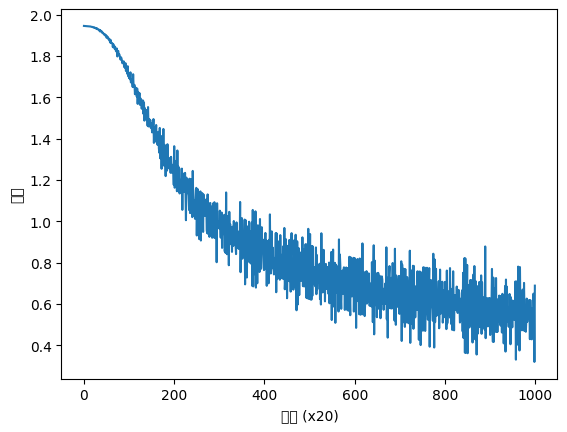

you [ 1.4914801  0.9135704 -1.0301975 -1.1084545  0.995609 ]
say [ 0.2581328 -1.140969   1.1676843  1.1264504 -1.1724561]
goodbye [ 0.36081648  1.037688   -0.8661371  -0.7240118   0.95096093]
and [ 1.8848871  -0.8243992   0.79512686  0.81734127 -0.72149426]
i [ 0.39608717  1.0353608  -0.86333245 -0.7149067   0.9499073 ]
hello [ 1.5014225  0.9152179 -1.0344906 -1.1171062  0.9735473]
. [-1.6387658 -1.1604378  1.225397   1.1591587 -1.2382888]


In [7]:

import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append('.')
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import preprocess, create_contexts_target, convert_one_hot


window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])


window사이즈가 변수인 word2vec 구현 (책 변형)

In [8]:
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW_many_window:
  def __init__(self, vocab_size, hidden_size,window_size):
    V, H = vocab_size, hidden_size

    #가중치 초기화
    W_in = 0.01 * np.random.randn(V,H).astype('f')
    W_out = 0.01 * np.random.randn(H,V).astype('f')

    # self.in_layer0 = MatMul(W_in)
    # self.in_layer1 = MatMul(W_in)
    # self.out_layer = MatMul(W_out) # 점수 나옴
    # self.loss_layer = SoftmaxWithLoss() #확률 나옴
    # for 문으로 구현, in_layer도 리스트로 구현
    self.in_layers = []
    for i in range(2 * window_size):
      self.in_layers.append(MatMul(W_in))
    self.out_layer = MatMul(W_out)
    self.loss_layer = SoftmaxWithLoss()


    #가중치와 기울기를 한 리스트에 모은다

    layers = self.in_layers + [self.out_layer]
    self.params, self.grads = [], []
    for layer in layers:
        self.params += layer.params
        self.grads += layer.grads

    # 인스턴스 변수에 단어의 분산 표현 저장
    self.word_vecs = W_in

  def forward(self, contexts, target):
    h = 0
    for i, layer in enumerate(self.in_layers):
      h += layer.forward(contexts[:, i])
    h *= 1/len(self.in_layers) # 2*window 개수 계층에 대해 평균을 구함

    score = self.out_layer.forward(h)
    loss = self.loss_layer.forward(score, target)
    return loss
  def backward(self, dout=1):
    ds = self.loss_layer.backward(dout)
    da = self.out_layer.backward(ds)
    da *= 1/len(self.in_layers) # 역전파도 2*window 개수 계층에 대해 평균을 구함
    for layer in self.in_layers:
            layer.backward(da)
    return None

window사이즈가 변수인 word2vec  traniner 구현

| 에폭 1 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 2 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 3 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 4 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 5 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 6 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 7 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 8 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 9 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 10 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 11 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 12 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 13 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 14 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 15 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 16 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 17 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 18 |  반복 1 / 1 | 시간 0[s] | 손실 1.95
| 에폭 19 |  반복 1 / 1 | 시간 0[s] | 손실 1.94
| 에폭 20 |  반복 1 / 1 | 시간 0[s] | 손실 1.94
| 에폭 21 |  반복 1 / 1 | 시간 0[s] | 손실 1.94
| 에폭 22 |  반복 1 / 1 | 시간 0[s] | 손실 1.94
| 에폭 23 |  반복 1 / 1 | 시간 0[s] | 손실 1.94
| 에폭 24 |  반복 1 / 1 | 시간 0[s] | 손실 1.94
| 에폭 25 |  반복 1 / 1 | 시간 0[s] | 손실 1.94
| 에폭 26 |

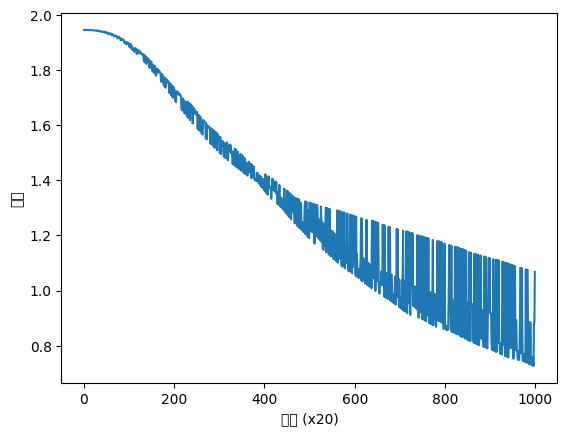

you [ 0.41387308 -1.0124481  -0.57436675 -0.97798103  0.5545373 ]
say [ 0.5252387  -1.1737489  -0.52347517 -1.1625471   0.50350124]
goodbye [ 0.668314   -1.0671842  -0.54121757 -1.1027623   0.5770935 ]
and [ 0.95014626  0.09693957 -0.96339893  0.10973971  0.9579685 ]
i [ 0.8035174  -0.22840476 -0.808407   -0.18224518  0.8201367 ]
hello [ 1.0296258   0.82804674 -1.0049955   0.65341127  1.0149181 ]
. [ 1.0151905  1.1563909 -1.0189344  1.1957448  0.9900761]


In [15]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append('.')
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import preprocess, create_contexts_target, convert_one_hot


window_size = 2 # 자유롭게 변경 가능
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW_many_window(vocab_size, hidden_size,window_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
| 에폭 5001 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5002 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5003 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5004 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5005 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5006 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5007 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5008 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5009 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5010 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5011 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5012 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5013 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5014 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5015 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5016 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5017 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5018 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5019 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5020 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5021 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5022 |  반복 1 / 8 | 시간 13[s] | 손실 0.00
| 에폭 5023 |  반복 1 

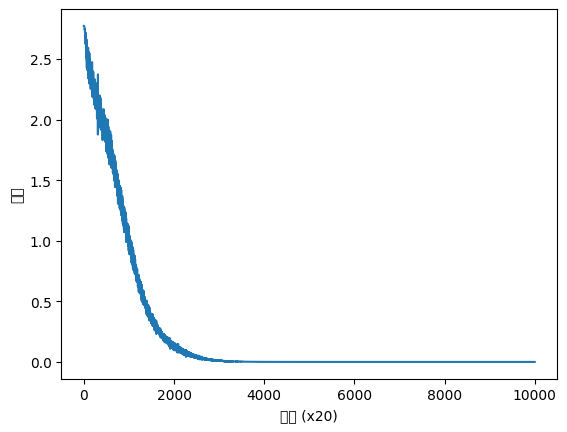

the [-1.205994  -5.987108  -5.9735036 -6.195067   4.793204 ]
cat [ -3.7374256    0.83134335  -1.2824643   -2.4650779  -14.569212  ]
sat [-4.7846084  -2.6191773   0.38741088 10.644986   -9.342255  ]
on [ 3.6568727  8.45145   -0.9691701  5.198412   4.43075  ]
mat [-2.2182412 -1.5247635 19.206865  -3.2959187  5.3441215]
. [11.679815   -0.58710593  0.47675964 -4.2348175  -3.1781213 ]
dog [-9.193264   5.840062  -7.3822217  4.0279803 -0.4295088]
rug [ -0.49159175 -18.702038     7.6256866   10.392044    -5.420032  ]
and [-7.7147646 -2.1097229  9.186252   4.136406  -9.056764 ]
are [ 0.6521202 -3.8999991  3.3643754  8.579182   4.1540375]
friends [ 5.921423   4.9654818 -9.079971   4.5865903  3.4251392]
they [-5.578539    7.0039907   9.004994   -8.8185625   0.32309204]
play [ 7.7122736  -0.19278006  7.8969145   4.584424   -2.7071416 ]
together [-2.8086882  11.456055   -0.59142417 -4.097552   -4.8187017 ]
every [-6.655562   -0.08641873  3.9852936  -0.40511516  8.598741  ]
day [-1.1986762  3.713982

In [21]:
import sys
sys.path.append('..')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
sys.path.append('.')
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import preprocess, create_contexts_target, convert_one_hot


window_size = 5 # 자유롭게 변경 가능
hidden_size = 5
batch_size = 3
max_epoch = 10000

#text = 'You say goodbye and I say hello.'
text = 'The cat sat on the mat. The dog sat on the rug. The cat and the dog are friends. They play together every day on the mat and the rug.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW_many_window(vocab_size, hidden_size,window_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

#window size가 학습 개선에 영향을 미치는지 확인 (cos similarity)
from common.util import most_similar

for query in ['say', 'cat', 'dog']:
    if query in word_to_id:
        print(f"\n[{query}] 와 가장 유사한 단어들:")
        most_similar(query, word_to_id, id_to_word, word_vecs, top=5)